In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = r"D:\ibrand_superprototype\eval\comparison\descriptor\scorecard.xlsx"

descriptor_df = pd.read_excel(
    FILE_PATH,
    sheet_name="per_image"
)

descriptor_df.head()

,provider,image_id,image,brand_item,vision_mood,mood,energy,color_temperature,texture,visual_style,sensory_metaphors,narrative,run_ok,schema_ok,no_leakage,leakage_term,mood_appropriate_1to5,overall_appropriate_1to5,error
0,kimi,advan_laptop,1.png,laptop,modern; professional; clean,modern; professional; clean,moderate,cool,metallic; matte; smooth,three-quarter angled product shot; minimalist;...,steel precision; glassine brightness,The laptop exudes a modern and professional au...,1,1,1,NaN,5,4,0
1,kimi,aqua,2.jpg,water bottle,refreshing; pure; clean,refreshing; pure; clean,high,cool,smooth; plastic; printed; transparent,centered product shot; minimal background,mountain mist; glassine clarity,This water bottle embodies the essence of puri...,1,1,1,NaN,5,5,0
2,kimi,batik_keris,4.jpg,batik shirt,elegant; confident; traditional; refined,elegant; confident; traditional; refined,moderate,warm,woven; embroidered; smooth fabric; structured ...,three-quarter portrait; angled pose; luxurious,golden sunset; velvet dusk; rich tapestry,The batik shirt exudes an air of elegance and ...,1,1,1,NaN,4,4,0
3,kimi,charles_and_keith,6.jpg,black chain shoulder bag,elegant; minimalist; urban chic,elegant; minimalist; urban chic,moderate,cool,pebbled leather; metallic chain; knitted fabric,close-up product shot; partial body context,sophisticated allure; urban sleekness,The black chain shoulder bag exudes an air of ...,1,1,1,NaN,5,5,0
4,kimi,erigo_shirt,8.jpg,t-shirt,elegant; serene; traditional; vibrant,elegant; serene; vibrant,moderate,cool,smooth; printed; soft fabric,back view centered composition; graphic print;...,cherry blossom tranquility; sunlit warmth; bir...,The t-shirt exudes an elegant and serene vibe ...,1,1,1,NaN,5,5,0


In [4]:
descriptor_df = descriptor_df.fillna(0)

In [6]:
descriptor_summary = (
    descriptor_df
    .groupby("provider")
    .agg(
        n=("image_id", "count"),
        run_success=("run_ok", "mean"),
        schema_success=("schema_ok", "mean"),
        no_leakage=("no_leakage", "mean"),
        mood_appropriateness=("mood_appropriate_1to5", "mean"),
        overall_appropriateness=("overall_appropriate_1to5", "mean")
    )
    .reset_index()
)

descriptor_summary

,provider,n,run_success,schema_success,no_leakage,mood_appropriateness,overall_appropriateness
0,deepseek,9,1.0,1.0,0.888889,4.555556,4.333333
1,gpt-4o,9,1.0,1.0,1.000000,4.555556,4.666667
2,kimi,9,1.0,1.0,1.000000,4.555556,4.222222


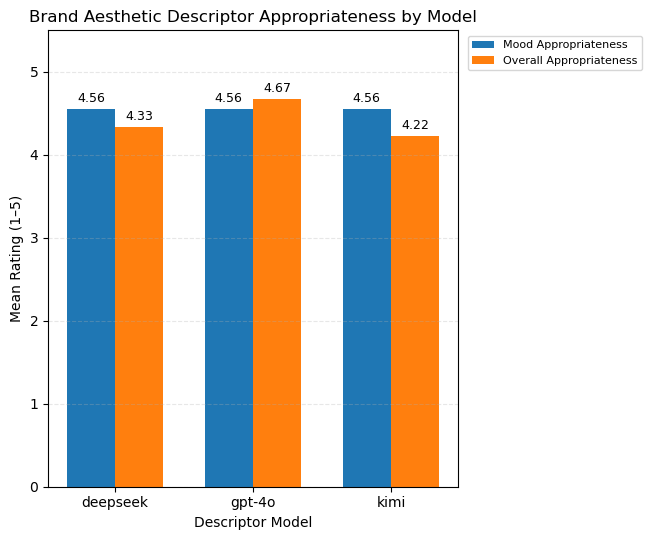

In [8]:
models = descriptor_summary["provider"]

mood_scores = descriptor_summary["mood_appropriateness"]
overall_scores = descriptor_summary["overall_appropriateness"]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5.5))

bars1 = ax.bar(
    x - width / 2,
    mood_scores,
    width,
    label="Mood Appropriateness"
)

bars2 = ax.bar(
    x + width / 2,
    overall_scores,
    width,
    label="Overall Appropriateness"
)

ax.set_title("Brand Aesthetic Descriptor Appropriateness by Model")
ax.set_xlabel("Descriptor Model")
ax.set_ylabel("Mean Rating (1–5)")

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylim(0, 5.5)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    fontsize=8,
    frameon=True
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.05,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout(rect=[0, 0, 0.83, 1])
plt.show()

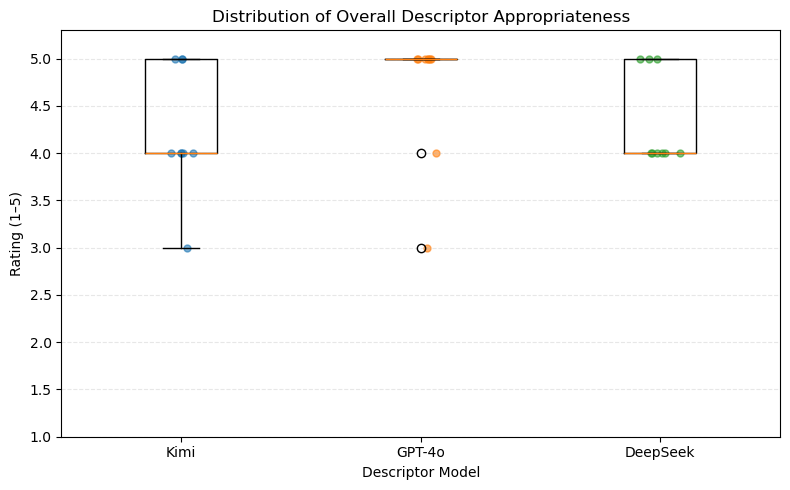

In [10]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

data = [
    descriptor_df.loc[
        descriptor_df["provider"] == "kimi",
        "overall_appropriate_1to5"
    ],
    descriptor_df.loc[
        descriptor_df["provider"] == "gpt-4o",
        "overall_appropriate_1to5"
    ],
    descriptor_df.loc[
        descriptor_df["provider"] == "deepseek",
        "overall_appropriate_1to5"
    ]
]

labels = ["Kimi", "GPT-4o", "DeepSeek"]

ax.boxplot(
    data,
    tick_labels=labels
)

# Add individual observations
for i, values in enumerate(data, start=1):
    jitter = np.random.normal(i, 0.04, size=len(values))

    ax.scatter(
        jitter,
        values,
        alpha=0.6,
        s=25
    )

ax.set_title("Distribution of Overall Descriptor Appropriateness")
ax.set_xlabel("Descriptor Model")
ax.set_ylabel("Rating (1–5)")
ax.set_ylim(1, 5.3)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()